In [1]:
!pip install requests pandas
!pip install scipy


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# %%
import requests
import pandas as pd

In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# %%
import os
API_KEY = os.environ.get("FOOTBALL_DATA_API_KEY")
headers = {"X-Auth-Token": API_KEY}

url = "https://api.football-data.org/v4/competitions/CL/matches"
response = requests.get(url, headers=headers)
data = response.json()

cl_matches = data["matches"]
print(f"Successfully fetched {len(cl_matches)} Champions League matches!")

Successfully fetched 144 Champions League matches!


In [5]:
# %%
first_match = cl_matches[0]

home_team = first_match['homeTeam']['name']
away_team = first_match['awayTeam']['name']
home_score = first_match['score']['fullTime']['home']
away_score = first_match['score']['fullTime']['away']

print(f"Match: {home_team} vs {away_team} - {home_score}:{away_score}")


Match: Club Brugge KV vs Aston Villa FC - 2:3


In [6]:
# %%
def build_elo_database(matches, initial_rating=1500, k_factor=30):
    """
    Builds an Elo rating database from historical match results.
    Higher k_factor = ratings react faster to recent results.
    """
    database = {}

    # First pass: register every team that appears anywhere, even in future fixtures
    for match in matches:
        home = match['homeTeam']['name']
        away = match['awayTeam']['name']
        if home not in database:
            database[home] = initial_rating
        if away not in database:
            database[away] = initial_rating

    # Second pass: only update ratings using matches that have actually finished
    for match in matches:
        if match['status'] != 'FINISHED':
            continue

        home = match['homeTeam']['name']
        away = match['awayTeam']['name']
        home_score = match['score']['fullTime']['home']
        away_score = match['score']['fullTime']['away']

        expected_home = 1 / (1 + 10 ** ((database[away] - database[home]) / 400))
        expected_away = 1 - expected_home

        if home_score > away_score:
            actual_home, actual_away = 1, 0
        elif home_score < away_score:
            actual_home, actual_away = 0, 1
        else:
            actual_home, actual_away = 0.5, 0.5

        database[home] += k_factor * (actual_home - expected_home)
        database[away] += k_factor * (actual_away - expected_away)

    return database

team_ratings = build_elo_database(cl_matches)

for team, rating in sorted(team_ratings.items(), key=lambda x: -x[1])[:10]:
    print(f"{team}: {rating:.0f}")

Aston Villa FC: 1515
PAE AEK: 1515
Real Madrid CF: 1515
Manchester City FC: 1515
Borussia Dortmund: 1515
Real Betis Balompié: 1515
FC Barcelona: 1515
VfB Stuttgart: 1515
Liverpool FC: 1515
Paris Saint-Germain FC: 1515


In [7]:
finished = [m for m in cl_matches if m['status'] == 'FINISHED']
print(f"Total finished matches: {len(finished)}")
print()
for m in finished[:5]:
    home = m['homeTeam']['name']
    away = m['awayTeam']['name']
    hs = m['score']['fullTime']['home']
    as_ = m['score']['fullTime']['away']
    print(f"{home} {hs} - {as_} {away}  (types: {type(hs).__name__}, {type(as_).__name__})")

Total finished matches: 18

Club Brugge KV 2 - 3 Aston Villa FC  (types: int, int)
PAE AEK 1 - 0 LASK Linz  (types: int, int)
Real Madrid CF 2 - 1 FC Internazionale Milano  (types: int, int)
FC Porto 0 - 2 Manchester City FC  (types: int, int)
Borussia Dortmund 3 - 2 Villarreal CF  (types: int, int)


In [8]:
# %%
def predict_match_probabilities(home_team, away_team, database):
    """
    Looks up two teams and outputs Win/Draw/Loss percentages
    based on their current Elo ratings.
    """
    if home_team not in database or away_team not in database:
        raise ValueError(f"Error: Make sure '{home_team}' and '{away_team}' are spelled correctly!")

    rating_diff = database[home_team] - database[away_team]

    # Base win probability from Elo formula, with home advantage baked in
    home_advantage = 65  # typical home-field Elo boost
    expected_home = 1 / (1 + 10 ** (-(rating_diff + home_advantage) / 400))

    # Convert win expectancy into win/draw/loss split
    # (draws are more likely when teams are close in rating)
    draw_prob = 0.28 - abs(rating_diff) / 2000  # tighter matches = more draws
    draw_prob = max(0.15, min(draw_prob, 0.30))

    win_prob = expected_home * (1 - draw_prob)
    loss_prob = (1 - expected_home) * (1 - draw_prob)

    return {
        "home_win_%": round(win_prob * 100, 1),
        "draw_%": round(draw_prob * 100, 1),
        "away_win_%": round(loss_prob * 100, 1)
    }

# Try it
result = predict_match_probabilities(home_team, away_team, team_ratings)
print(result)
    
    



{'home_win_%': 40.4, 'draw_%': 26.5, 'away_win_%': 33.1}


In [9]:
# %%
import random
from collections import defaultdict

def simulate_season(matches, database, n_simulations=5000):
    """
    Simulates the remaining fixtures many times using current Elo ratings,
    then tallies how often each team finishes in each position.
    """
    finished = [m for m in matches if m['status'] == 'FINISHED']
    remaining = [m for m in matches if m['status'] != 'FINISHED']

    base_points = defaultdict(int)
    for m in finished:
        home, away = m['homeTeam']['name'], m['awayTeam']['name']
        hs, as_ = m['score']['fullTime']['home'], m['score']['fullTime']['away']
        if hs > as_:
            base_points[home] += 3
        elif hs < as_:
            base_points[away] += 3
        else:
            base_points[home] += 1
            base_points[away] += 1

    position_counts = defaultdict(lambda: defaultdict(int))

    for _ in range(n_simulations):
        points = dict(base_points)

        for m in remaining:
            home, away = m['homeTeam']['name'], m['awayTeam']['name']
            if home not in database or away not in database:
                continue

            probs = predict_match_probabilities(home, away, database)
            roll = random.random() * 100

            if roll < probs['home_win_%']:
                points[home] = points.get(home, 0) + 3
                points[away] = points.get(away, 0)
            elif roll < probs['home_win_%'] + probs['draw_%']:
                points[home] = points.get(home, 0) + 1
                points[away] = points.get(away, 0) + 1
            else:
                points[away] = points.get(away, 0) + 3
                points[home] = points.get(home, 0)

        ranked = sorted(points.items(), key=lambda x: -x[1])
        for position, (team, _) in enumerate(ranked, start=1):
            position_counts[team][position] += 1

    return position_counts, n_simulations

position_counts, n_sims = simulate_season(cl_matches, team_ratings)

print("Team — chance of finishing top 8:")
top8_probs = []
for team, positions in position_counts.items():
    top8_count = sum(count for pos, count in positions.items() if pos <= 8)
    top8_probs.append((team, top8_count / n_sims * 100))

for team, pct in sorted(top8_probs, key=lambda x: -x[1])[:15]:
    print(f"{team}: {pct:.1f}%")

Team — chance of finishing top 8:
Aston Villa FC: 44.9%
Real Betis Balompié: 42.0%
Manchester City FC: 41.8%
VfB Stuttgart: 40.9%
Real Madrid CF: 40.4%
Arsenal FC: 39.8%
Borussia Dortmund: 38.8%
Liverpool FC: 38.8%
Racing Club de Lens: 37.6%
PAE AEK: 37.4%
Paris Saint-Germain FC: 37.3%
FC Barcelona: 34.7%
Manchester United FC: 34.6%
FC Bayern München: 34.2%
Sporting Clube de Portugal: 33.8%


In [10]:
# %%
def calculate_form_factor(team, matches, num_recent=5):
    """"
    Looks at a team's most recent finished matches and returns a form Multiplier: >1.0 means hot streak, <1.0 means cold streak.
    """
    team_matches = []
    for m in matches:
        if m['status'] != 'FINISHED':
            continue
        home = m['homeTeam']['name']
        away = m['awayTeam']['name']
        if team not in (home, away):
            continue
        team_matches.append(m)

    # Sort by date, most recent first
    team_matches.sort(key=lambda m: m['utcDate'])
    recent = team_matches[-num_recent:]

    if not recent:
        return 1.0 # no data yet, neutral form

    points = 0
    for m in recent: 
        home = m['homeTeam']['name']
        hs,as_ = m['score']['fullTime']['home'], m['score']['fullTime']['away']
        is_home = (home == team)

        if hs == as_: 
            points += 1 
        elif (hs > as_ and is_home) or (as_ > hs and not is_home):
            points += 3 

    # Max possible points = num_recent * 3 (all wins)
    max_points = len(recent) * 3 
    form_ratio = points / max_points #o.0 to 1.0

    # Convert to a multiplier centered at 1.0 (0.85 to 1.15 range)
    return 0.85 + (form_ratio * 0.3) 

def predict_match_probabilities_with_form(home_team, away_team, database, matches):
    """
    Sames as predict match_probabilities, but adjusts each team's effective rating using their recent form before computing odds.
    """
    if home_team not in database or away_team not in database:
        raise ValueError(f"Error: Make sure '{home_team}' and '{away_team}' are spelled correctly!")

    home_form = calculate_form_factor(home_team, matches)
    away_form = calculate_form_factor(away_team, matches)

    # Apply form as a multiplier on effective rating
    effective_home_rating = database[home_team] * home_form
    effective_away_rating = database[away_team] * away_form

    rating_diff = effective_home_rating - effective_away_rating
    home_advantage = 65
    expected_home = 1 / (1 + 10 ** (-(rating_diff + home_advantage) / 400))

    draw_prob = 0.28 - abs(rating_diff) / 2000
    draw_prob = max(0.15, min(draw_prob, 0.30))

    win_prob = expected_home * (1 - draw_prob)
    loss_prob = (1 - expected_home) * (1 - draw_prob)

    return {
        "home_win_%": round(win_prob * 100, 1),
        "draw_%": round(draw_prob * 100, 1),
        "away_win_%": round(loss_prob * 100, 1),
        "home_form": round(home_form, 2),
        "away_form": round(away_form, 2)
    }

# Try it 
result = predict_match_probabilities_with_form(home_team, away_team, team_ratings, cl_matches)
print(result)



{'home_win_%': 7.1, 'draw_%': 15.0, 'away_win_%': 77.9, 'home_form': 0.85, 'away_form': 1.15}


In [11]:
# %%
stages_seen = set(m['stage'] for m in cl_matches)
print(stages_seen)

{'LEAGUE_STAGE'}


In [12]:
# %%
def simulate_leg(home_team, away_team, database, matches):
    """Simulates one leg using form-adjusted probabilities, returns the winner or None for a draw."""
    probs = predict_match_probabilities_with_form(home_team, away_team, database, matches)
    roll = random.random() * 100
    if roll < probs['home_win_%']:
        return home_team
    elif roll < probs['home_win_%'] + probs['draw_%']:
        return None
    else:
        return away_team


def simulate_knockout_tie(team_a, team_b, database, matches):
    """Simulates a two-legged tie (team_a home first, team_b home second)."""
    leg1_winner = simulate_leg(team_a, team_b, database, matches)
    leg2_winner = simulate_leg(team_b, team_a, database, matches)

    wins_a = sum(1 for w in [leg1_winner, leg2_winner] if w == team_a)
    wins_b = sum(1 for w in [leg1_winner, leg2_winner] if w == team_b)

    if wins_a > wins_b:
        return team_a
    elif wins_b > wins_a:
        return team_b
    else:
        rating_diff = database[team_a] - database[team_b]
        prob_a = 1 / (1 + 10 ** (-rating_diff / 400))
        return team_a if random.random() < prob_a else team_b


def get_real_aggregate_winner(team_a, team_b, leg_matches):
    agg = {team_a: 0, team_b: 0}
    for m in leg_matches:
        h, a = m['homeTeam']['name'], m['awayTeam']['name']
        hs, as_ = m['score']['fullTime']['home'], m['score']['fullTime']['away']
        agg[h] += hs
        agg[a] += as_
    if agg[team_a] != agg[team_b]:
        return team_a if agg[team_a] > agg[team_b] else team_b
    return None


def simulate_knockout_round(round_matches, database, matches):
    ties = {}
    for m in round_matches:
        home, away = m['homeTeam']['name'], m['awayTeam']['name']
        pair = tuple(sorted([home, away]))
        ties.setdefault(pair, []).append(m)

    winners = []
    for (team_a, team_b), leg_matches in ties.items():
        finished_legs = [m for m in leg_matches if m['status'] == 'FINISHED']

        if len(finished_legs) == len(leg_matches):
            winner = get_real_aggregate_winner(team_a, team_b, leg_matches)
            if winner is None:
                rating_diff = database[team_a] - database[team_b]
                prob_a = 1 / (1 + 10 ** (-rating_diff / 400))
                winner = team_a if random.random() < prob_a else team_b
        else:
            winner = simulate_knockout_tie(team_a, team_b, database, matches)

        winners.append(winner)

    return winners


def simulate_tournament(matches, database, n_simulations=5000):
    stages_order = ['ROUND_OF_16', 'QUARTER_FINALS', 'SEMI_FINALS', 'FINAL']
    champion_counts = defaultdict(int)

    for _ in range(n_simulations):
        current_teams = None

        for stage in stages_order:
            stage_matches = [m for m in matches if m.get('stage') == stage]

            if stage_matches:
                current_teams = simulate_knockout_round(stage_matches, database, matches)
            elif current_teams and len(current_teams) > 1:
                shuffled = current_teams[:]
                random.shuffle(shuffled)
                current_teams = [
                    simulate_knockout_tie(shuffled[i], shuffled[i + 1], database, matches)
                    for i in range(0, len(shuffled) - 1, 2)
                ]

        if current_teams and len(current_teams) == 1:
            champion_counts[current_teams[0]] += 1

    print("Champion probability:")
    for team, count in sorted(champion_counts.items(), key=lambda x: -x[1])[:10]:
        print(f"{team}: {count / n_simulations * 100:.1f}%")

    return champion_counts

champion_counts = simulate_tournament(cl_matches, team_ratings, n_simulations=5000)

Champion probability:


In [13]:
stages_seen = set(m['stage'] for m in cl_matches)
print(stages_seen)

{'LEAGUE_STAGE'}


In [14]:
# %%
def project_league_phase_standings(matches, database, n_simulations=5000):
    finished = [m for m in matches if m['status']=='FINISHED' and m['stage']=='LEAGUE_STAGE']
    remaining = [m for m in matches if m['status']!='FINISHED' and m['stage']=='LEAGUE_STAGE']

    base_points = defaultdict(int)
    for m in finished:
        home, away = m['homeTeam']['name'], m['awayTeam']['name']
        hs, as_ = m['score']['fullTime']['home'], m['score']['fullTime']['away']
        if hs > as_: base_points[home] += 3
        elif hs < as_: base_points[away] += 3
        else: base_points[home] += 1; base_points[away] += 1

    position_sum = defaultdict(float)
    for _ in range(n_simulations):
        points = dict(base_points)
        for m in remaining:
            home, away = m['homeTeam']['name'], m['awayTeam']['name']
            if home not in database or away not in database: continue
            probs = predict_match_probabilities_with_form(home, away, database, matches)
            roll = random.random() * 100
            if roll < probs['home_win_%']: points[home] = points.get(home,0)+3; points[away] = points.get(away,0)
            elif roll < probs['home_win_%']+probs['draw_%']: points[home]=points.get(home,0)+1; points[away]=points.get(away,0)+1
            else: points[away]=points.get(away,0)+3; points[home]=points.get(home,0)
        ranked = sorted(points.items(), key=lambda x: -x[1])
        for pos, (team, _) in enumerate(ranked, start=1):
            position_sum[team] += pos

    return {t: s/n_simulations for t, s in position_sum.items()}


def simulate_projected_knockouts(matches, database, n_simulations=5000):
    avg_position = project_league_phase_standings(matches, database)
    ranked_teams = [t for t, _ in sorted(avg_position.items(), key=lambda x: x[1])]

    auto_ro16, playoff = ranked_teams[:8], ranked_teams[8:24]
    champion_counts = defaultdict(int)

    for _ in range(n_simulations):
        n = len(playoff)
        playoff_winners = [simulate_knockout_tie(playoff[i], playoff[n-1-i], database, matches) for i in range(n//2)]
        field = auto_ro16 + playoff_winners
        random.shuffle(field)
        while len(field) > 1:
            field = [simulate_knockout_tie(field[i], field[i+1], database, matches) for i in range(0, len(field)-1, 2)]
        champion_counts[field[0]] += 1

    print("Projected champion probability:")
    for team, count in sorted(champion_counts.items(), key=lambda x: -x[1])[:10]:
        print(f"{team}: {count/n_simulations*100:.1f}%")
    return champion_counts

simulate_projected_knockouts(cl_matches, team_ratings)

Projected champion probability:
Manchester City FC: 7.1%
VfB Stuttgart: 6.8%
Real Madrid CF: 6.7%
Liverpool FC: 6.7%
Real Betis Balompié: 6.6%
Borussia Dortmund: 6.6%
Manchester United FC: 6.5%
PAE AEK: 6.3%
Racing Club de Lens: 6.3%
Aston Villa FC: 6.2%


defaultdict(int,
            {'Manchester United FC': 326,
             'Real Madrid CF': 336,
             'FC Bayern München': 309,
             'Paris Saint-Germain FC': 251,
             'Real Betis Balompié': 328,
             'Liverpool FC': 336,
             'Sporting Clube de Portugal': 288,
             'Como 1907': 276,
             'Racing Club de Lens': 315,
             'VfB Stuttgart': 338,
             'FC Barcelona': 283,
             'Arsenal FC': 301,
             'Aston Villa FC': 312,
             'PAE AEK': 317,
             'Manchester City FC': 354,
             'Borussia Dortmund': 328,
             'AS Roma': 1,
             'Fenerbahçe SK': 1})

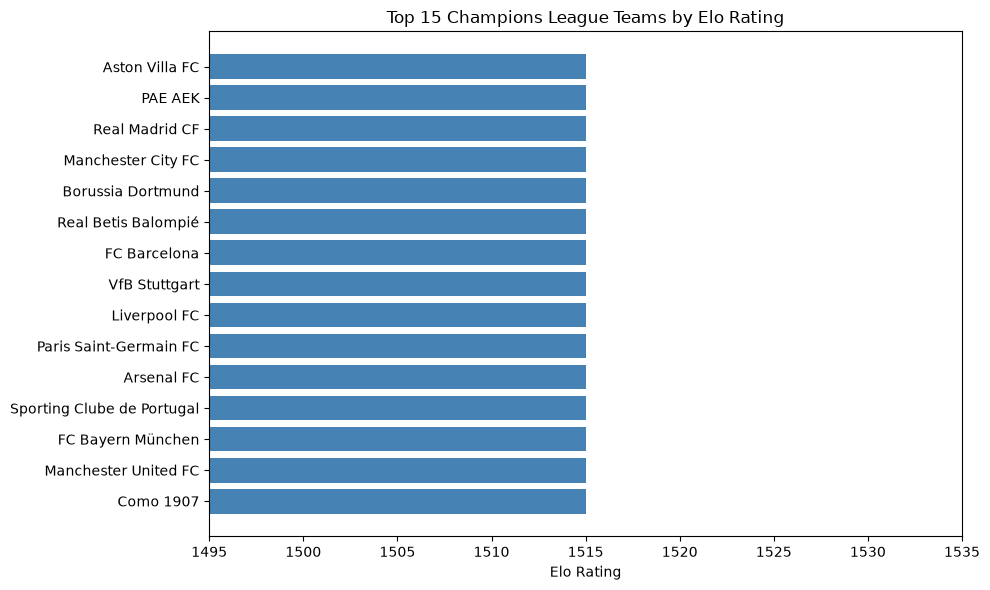

In [15]:
# %%
import matplotlib.pyplot as plt

def plot_team_ratings(database, top_n=36):
    """Bar chart of the top N teams by current Elo rating.""" 
    ranked = sorted(database.items(), key=lambda x: -x[1])[:top_n] 
    teams = [t for t, _ in ranked] 
    ratings = [r for _, r in ranked]

    plt.figure(figsize=(10, 6))
    plt.barh(teams[::-1], ratings[::-1], color='steelblue')
    plt.xlabel('Elo Rating')
    plt.title(f'Top {top_n} Champions League Teams by Elo Rating')
    plt.xlim(min(ratings) - 20, max(ratings) + 20)
    plt.tight_layout()
    plt.show()

plot_team_ratings(team_ratings, top_n=15)


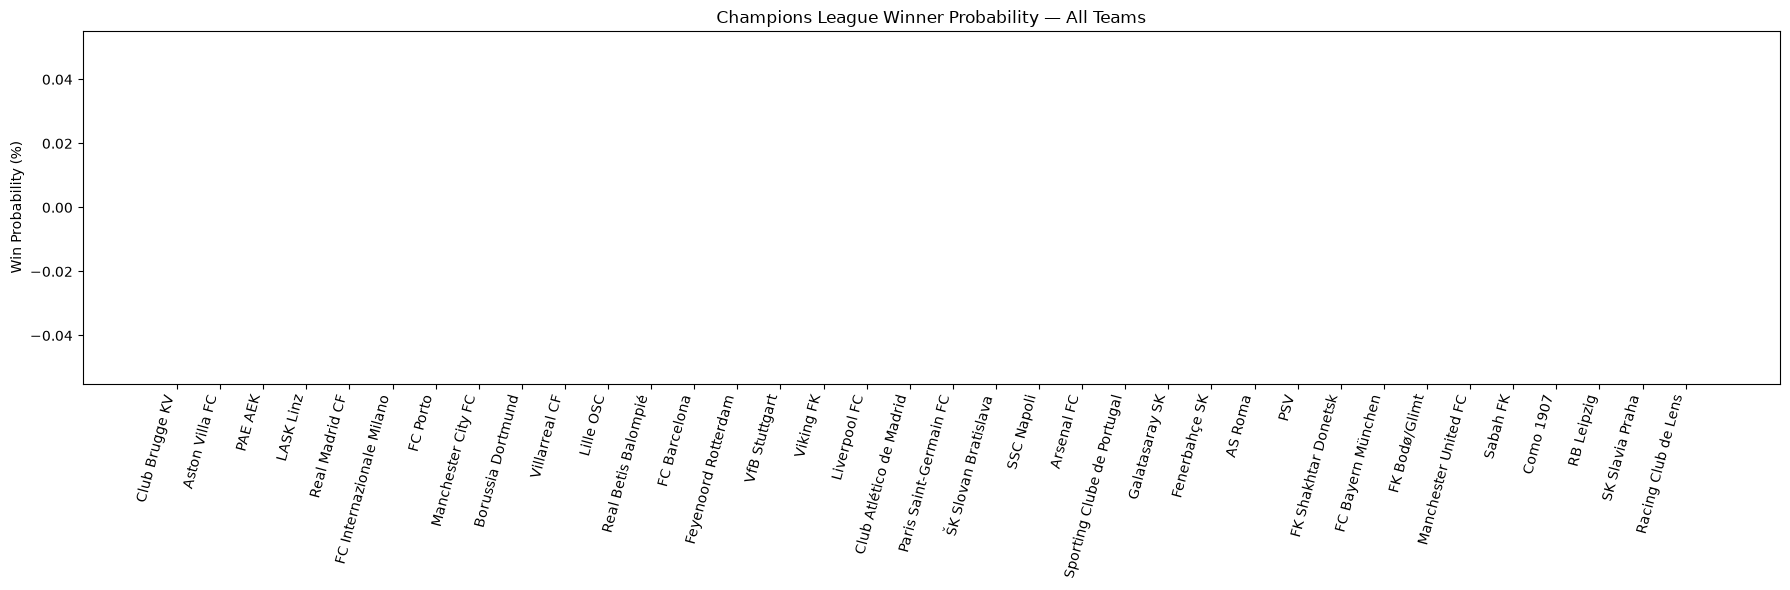

In [16]:
# %%
def plot_champion_probabilities(champion_counts, database, n_simulations, top_n=None):
    all_teams = {team: champion_counts.get(team, 0) for team in database}
    ranked = sorted(all_teams.items(), key=lambda x: -x[1])
    if top_n:
        ranked = ranked[:top_n]

    teams = [t for t, _ in ranked]
    probs = [count / n_simulations * 100 for _, count in ranked]

    plt.figure(figsize=(max(10, len(teams) * 0.5), 6))
    plt.bar(teams, probs, color='firebrick')
    plt.ylabel('Win Probability (%)')
    plt.title('Champions League Winner Probability — All Teams')
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.show()

plot_champion_probabilities(champion_counts, team_ratings, n_simulations=5000)

In [17]:
finished = [m for m in cl_matches if m['status'] == 'FINISHED']
print(f"Finished matches: {len(finished)}")
print(f"Sample ratings: {list(team_ratings.items())[:5]}")

Finished matches: 18
Sample ratings: [('Club Brugge KV', 1485.0), ('Aston Villa FC', 1515.0), ('PAE AEK', 1515.0), ('LASK Linz', 1485.0), ('Real Madrid CF', 1515.0)]



New results (18 finished) - recalculating...
Projected champion probability:
Borussia Dortmund: 7.5%
Liverpool FC: 6.6%
VfB Stuttgart: 6.6%
Manchester City FC: 6.5%
FC Bayern München: 6.4%
Arsenal FC: 6.3%
PAE AEK: 6.3%
Real Madrid CF: 6.2%
Real Betis Balompié: 6.2%
FC Barcelona: 6.1%
DEBUG: champion_counts has 19 teams, total sims counted: 5000
DEBUG champion_counts sample: [('FC Bayern München', 321), ('Real Madrid CF', 312), ('Aston Villa FC', 296), ('Manchester City FC', 324), ('Paris Saint-Germain FC', 305)]
DEBUG updated_ratings sample: [('Club Brugge KV', 1485.0), ('Aston Villa FC', 1515.0), ('PAE AEK', 1515.0), ('LASK Linz', 1485.0), ('Real Madrid CF', 1515.0)]
DEBUG name overlap: 19 of 19 champion_counts teams found in updated_ratings


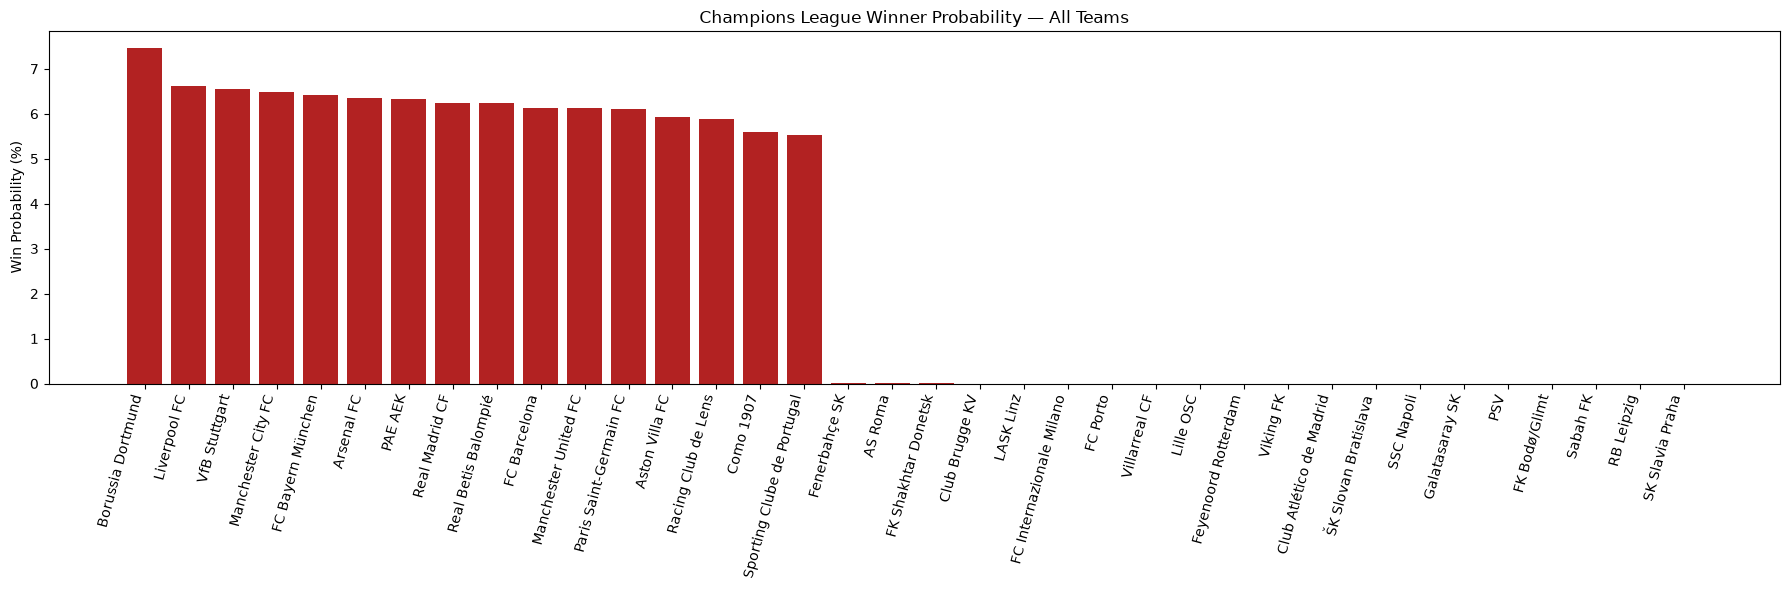

No change (18 finished).
No change (18 finished).
No change (18 finished).
No change (18 finished).


In [18]:
# %%
import time

def run_live_tracker(url, headers, poll_interval_seconds=300, max_checks=5):
    last_finished_count = -1
    checks = 0

    while True:
        response = requests.get(url, headers=headers)
        matches = response.json()["matches"]
        finished_count = sum(1 for m in matches if m['status'] == 'FINISHED')

        if finished_count != last_finished_count:
            print(f"\nNew results ({finished_count} finished) - recalculating...")
            updated_ratings = build_elo_database(matches)
            champion_counts = simulate_projected_knockouts(matches, updated_ratings, n_simulations=5000)

            print(f"DEBUG: champion_counts has {len(champion_counts)} teams, total sims counted: {sum(champion_counts.values())}")
            print("DEBUG champion_counts sample:", list(champion_counts.items())[:5])
            print("DEBUG updated_ratings sample:", list(updated_ratings.items())[:5])
            overlap = set(champion_counts.keys()) & set(updated_ratings.keys())
            print(f"DEBUG name overlap: {len(overlap)} of {len(champion_counts)} champion_counts teams found in updated_ratings")

            plot_champion_probabilities(champion_counts, updated_ratings, n_simulations=5000)
            last_finished_count = finished_count
        else:
            print(f"No change ({finished_count} finished).")

        checks += 1
        if max_checks and checks >= max_checks:
           break
        time.sleep(poll_interval_seconds)

run_live_tracker(url, headers, poll_interval_seconds=30, max_checks=5)